# 📈 Meta-Labeling — ML Training

Loads pre-built trade+feature data from `feature_pipeline_001.ipynb` and trains
three calibrated classifiers (XGBoost, LightGBM, CatBoost) with purged CV.

**Prerequisites**: run `feature_pipeline_001.ipynb` first to generate:
- `all_trades_with_features.h5`
- `feature_columns.json`


In [8]:
import sys, os, json, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 100


In [9]:
# ── Load pipeline outputs (run feature_pipeline_001.ipynb first) ─────────
training_df = pd.read_hdf('all_trades_with_features.h5', 'data')
training_df['entry_date'] = pd.to_datetime(training_df['entry_date'])
training_df['exit_date']  = pd.to_datetime(training_df['exit_date'])
# VBT fill timestamp is execution day; signal bar is the prior session.
training_df['entry_date'] = training_df['entry_date'] - pd.offsets.BDay(1)
training_df = training_df.sort_values('entry_date').reset_index(drop=True)

with open('feature_columns.json') as f:
    training_feature_columns = json.load(f)

# Filter to columns that actually exist (guard against schema drift)
training_feature_columns = [c for c in training_feature_columns if c in training_df.columns]

print(f'Trades loaded  : {len(training_df):,}')
print(f'Date range     : {training_df["entry_date"].min().date()} → {training_df["entry_date"].max().date()}')
print(f'Win rate       : {training_df["Y"].mean():.2%}')
print(f'Feature count  : {len(training_feature_columns)}')


Trades loaded  : 14,010
Date range     : 2017-07-03 → 2026-05-29
Win rate       : 31.19%
Feature count  : 59


# 7. Time-Ordered Train/Test Split

## 🚨 Most Critical Fix

**Original notebook:**
```python
train_test_split(X, y, test_size=0.2, random_state=42, shuffle=True)  # WRONG!
```

This randomly mixes time periods — your model trains on 2023 data and tests on 2018 data, which is **future-leakage in reverse**. Backtest results look great but live trading collapses.

**Correct approach:** Split chronologically. Train on past, test on future.


In [10]:
# === Chronological split (no shuffle!) ===
TRAIN_END_DATE = '2022-06-30'   # ~80/20 split (2014-2022 train, 2022-2023 test)
EMBARGO_DAYS   = 10              # gap between train and test

train_mask = training_df['entry_date'] <= pd.Timestamp(TRAIN_END_DATE)
embargo_start = pd.Timestamp(TRAIN_END_DATE)
embargo_end   = embargo_start + pd.Timedelta(days=EMBARGO_DAYS)
test_mask = training_df['entry_date'] > embargo_end

X_train = training_df.loc[train_mask, training_feature_columns].copy()
y_train = training_df.loc[train_mask, 'Y'].copy()
X_test  = training_df.loc[test_mask,  training_feature_columns].copy()
y_test  = training_df.loc[test_mask,  'Y'].copy()
returns_test = training_df.loc[test_mask, 'net_return'].copy()
dates_train  = training_df.loc[train_mask, 'entry_date'].copy()
dates_test   = training_df.loc[test_mask,  'entry_date'].copy()
exit_dates_train = training_df.loc[train_mask, 'exit_date'].copy()

print(f"Train period: {dates_train.min()} → {dates_train.max()} ({len(X_train)} trades)")
print(f"  → Embargo: {embargo_start.date()} to {embargo_end.date()} ({EMBARGO_DAYS} days)")
print(f"Test period:  {dates_test.min()} → {dates_test.max()} ({len(X_test)} trades)")
print(f"\nTrain label balance: {y_train.value_counts(normalize=True).to_dict()}")
print(f"Test label balance:  {y_test.value_counts(normalize=True).to_dict()}")

Train period: 2017-07-03 00:00:00 → 2022-06-30 00:00:00 (7861 trades)
  → Embargo: 2022-06-30 to 2022-07-10 (10 days)
Test period:  2022-07-12 00:00:00 → 2026-05-29 00:00:00 (6117 trades)

Train label balance: {0: 0.6658185981427299, 1: 0.3341814018572701}
Test label balance:  {0: 0.7162007520026157, 1: 0.2837992479973843}


In [11]:
# === Scaling — fit on train ONLY, transform test ===
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index,
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=X_test.columns,
    index=X_test.index,
)

# 🚨 NOTE: We do NOT use SMOTE.
# SMOTE creates synthetic samples by interpolating between neighbors —
# this doesn't make sense for time-series financial data and can leak info.
# Instead, we use class_weight='balanced' or scale_pos_weight in models.

print(f"X_train_scaled: {X_train_scaled.shape}")
print(f"X_test_scaled:  {X_test_scaled.shape}")

X_train_scaled: (7861, 59)
X_test_scaled:  (6117, 59)


# 8. Compute Sample Uniqueness Weights

When trades have **overlapping holding periods**, their labels are not independent — they share return information. López de Prado's solution: **down-weight overlapping samples** during training.


In [12]:
def compute_sample_uniqueness(entry_dates: pd.Series, exit_dates: pd.Series) -> np.ndarray:
    """
    Compute López de Prado's sample uniqueness:
    For each sample, count how many other samples' [entry, exit] intervals overlap with it.
    Weight = 1 / overlap_count (then normalized).
    """
    n = len(entry_dates)
    entries = entry_dates.values
    exits   = exit_dates.values
    overlaps = np.zeros(n)

    for i in range(n):
        # Count concurrent samples (including self)
        overlaps[i] = ((entries <= exits[i]) & (exits >= entries[i])).sum()

    weights = 1.0 / np.maximum(overlaps, 1)
    return weights / weights.mean()  # normalize to mean=1


train_weights = compute_sample_uniqueness(
    dates_train.reset_index(drop=True),
    exit_dates_train.reset_index(drop=True),
)

print(f"Train sample weights:")
print(f"  min:    {train_weights.min():.3f}")
print(f"  median: {np.median(train_weights):.3f}")
print(f"  max:    {train_weights.max():.3f}")
print(f"  Effective sample size: {(train_weights.sum())**2 / (train_weights**2).sum():.0f} / {len(train_weights)}")

Train sample weights:
  min:    0.124
  median: 0.917
  max:    10.591
  Effective sample size: 5742 / 7861


# 9. Purged & Embargoed K-Fold Cross-Validation

## Why?

Standard `KFold` randomly shuffles → leakage.
Standard `TimeSeriesSplit` doesn't purge overlapping samples.

**Purged & Embargoed K-Fold** (López de Prado, AFML Ch. 7):
- Splits data chronologically
- **Purges** training samples whose holding period overlaps the test set
- **Embargo**: removes samples right after the test fold to prevent serial-correlation leakage


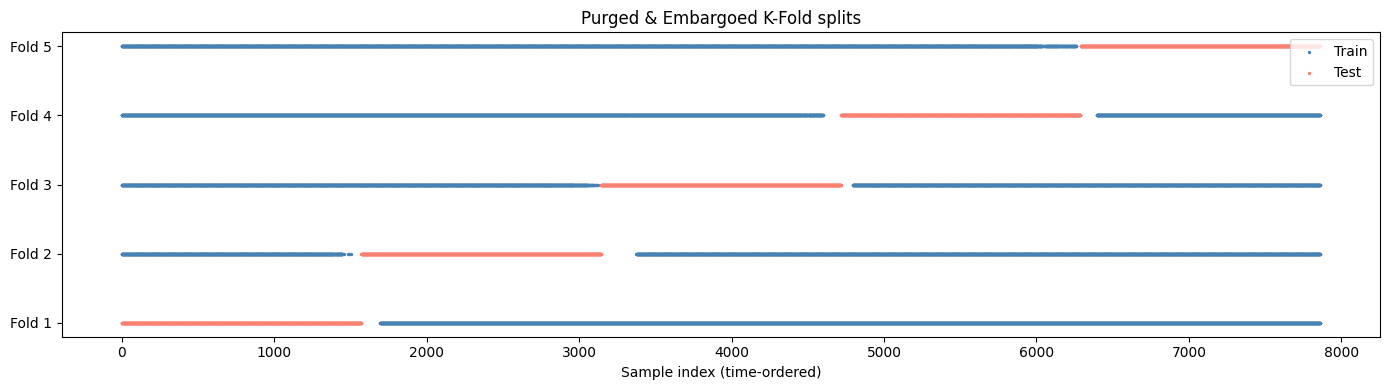

In [13]:
class PurgedKFold:
    """
    Purged & Embargoed K-Fold for time-series with overlapping labels.

    Parameters
    ----------
    n_splits : int
    entry_dates : pd.Series of trade entry timestamps
    exit_dates  : pd.Series of trade exit timestamps
    embargo_pct : float, fraction of dataset to embargo after each test fold
    """
    def __init__(self, n_splits=5, entry_dates=None, exit_dates=None, embargo_pct=0.01):
        self.n_splits    = n_splits
        self.entry_dates = entry_dates.reset_index(drop=True)
        self.exit_dates  = exit_dates.reset_index(drop=True)
        self.embargo_pct = embargo_pct

    def split(self, X, y=None, groups=None):
        n = len(X)
        indices = np.arange(n)
        embargo_n = int(n * self.embargo_pct)

        # Test folds are contiguous chunks ordered in time
        test_ranges = np.array_split(indices, self.n_splits)

        for test_idx in test_ranges:
            test_start_t = self.entry_dates.iloc[test_idx[0]]
            test_end_t   = self.exit_dates.iloc[test_idx[-1]]

            train_mask = np.ones(n, dtype=bool)
            train_mask[test_idx] = False

            # Purge: remove training samples whose [entry, exit] overlaps test period
            for i in indices[train_mask]:
                if (self.entry_dates.iloc[i] <= test_end_t) and \
                   (self.exit_dates.iloc[i]  >= test_start_t):
                    train_mask[i] = False

            # Embargo: remove samples right after test fold
            embargo_end = min(test_idx[-1] + 1 + embargo_n, n)
            train_mask[test_idx[-1]+1 : embargo_end] = False

            train_idx = indices[train_mask]
            yield train_idx, test_idx

    def get_n_splits(self, X=None, y=None, groups=None):
        return self.n_splits


# === Build CV splitter for training set ===
purged_cv = PurgedKFold(
    n_splits=5,
    entry_dates=dates_train,
    exit_dates=exit_dates_train,
    embargo_pct=0.01,
)

# Sanity check: visualize splits
fig, ax = plt.subplots(figsize=(14, 4))
for fold, (tr, te) in enumerate(purged_cv.split(X_train_scaled)):
    ax.scatter(tr, [fold]*len(tr), c='steelblue', s=2, label='Train' if fold==0 else None)
    ax.scatter(te, [fold]*len(te), c='salmon',    s=2, label='Test'  if fold==0 else None)
ax.set_yticks(range(5))
ax.set_yticklabels([f'Fold {i+1}' for i in range(5)])
ax.set_xlabel('Sample index (time-ordered)')
ax.set_title('Purged & Embargoed K-Fold splits')
ax.legend()
plt.tight_layout()
plt.show()

# 10. Evaluation Helpers

We evaluate models with metrics that matter for **trading P&L**, not just classification accuracy:
- **AUC** — discrimination ability
- **Precision @ threshold** — how often "predicted win" is actually a win
- **Sharpe lift** — improvement in risk-adjusted return when using model as a filter
- **Trade reduction** — % of bad trades successfully filtered


In [14]:
from sklearn.metrics import (
    roc_auc_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, brier_score_loss,
)


def evaluate_meta_model(
    y_true: pd.Series,
    y_proba: np.ndarray,
    returns: pd.Series,
    threshold: float = 0.55,
) -> dict:
    """Compute trading-relevant evaluation metrics."""
    y_pred = (y_proba >= threshold).astype(int)

    # Filter strategy returns: only take trades where model says "win"
    take_mask = y_pred == 1
    base_returns     = returns
    filtered_returns = returns[take_mask]

    def sharpe(r):
        return r.mean() / (r.std() + 1e-9) * np.sqrt(252) if len(r) > 1 else 0

    metrics = {
        'auc':              roc_auc_score(y_true, y_proba),
        'brier_score':      brier_score_loss(y_true, y_proba),
        'precision':        precision_score(y_true, y_pred, zero_division=0),
        'recall':           recall_score(y_true, y_pred, zero_division=0),
        'f1':               f1_score(y_true, y_pred, zero_division=0),
        'trades_taken':     int(take_mask.sum()),
        'trades_filtered':  int((~take_mask).sum()),
        'pct_filtered':     float((~take_mask).mean()),
        'base_mean_ret':    float(base_returns.mean()),
        'filt_mean_ret':    float(filtered_returns.mean()) if len(filtered_returns) else 0,
        'base_sharpe':      sharpe(base_returns),
        'filt_sharpe':      sharpe(filtered_returns) if len(filtered_returns) > 1 else 0,
    }
    metrics['sharpe_lift'] = metrics['filt_sharpe'] - metrics['base_sharpe']
    return metrics


def plot_evaluation(model_name, y_true, y_proba, returns, threshold=0.55):
    metrics = evaluate_meta_model(y_true, y_proba, returns, threshold)
    y_pred = (y_proba >= threshold).astype(int)

    fig, axes = plt.subplots(1, 3, figsize=(16, 4))

    # Confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
                xticklabels=['Pred Loss', 'Pred Win'],
                yticklabels=['Actual Loss', 'Actual Win'])
    axes[0].set_title(f'{model_name} — Confusion @ thr={threshold}')

    # Probability distribution
    axes[1].hist(y_proba[y_true==0], bins=30, alpha=0.5, label='Actual Loss', color='red')
    axes[1].hist(y_proba[y_true==1], bins=30, alpha=0.5, label='Actual Win',  color='green')
    axes[1].axvline(threshold, color='black', linestyle='--', label=f'thr={threshold}')
    axes[1].set_xlabel('Predicted P(win)')
    axes[1].set_title(f'{model_name} — Probability Distribution')
    axes[1].legend()

    # Returns: filtered vs base
    rets_base = returns
    rets_filt = returns[y_pred==1]
    axes[2].hist(rets_base, bins=40, alpha=0.4, label=f'All (μ={rets_base.mean():.2%})', color='gray')
    if len(rets_filt) > 0:
        axes[2].hist(rets_filt, bins=40, alpha=0.6,
                     label=f'Filtered (μ={rets_filt.mean():.2%})', color='green')
    axes[2].axvline(0, color='black', linestyle='-', alpha=0.3)
    axes[2].set_xlabel('Net Return')
    axes[2].set_title(f'{model_name} — Return Distributions')
    axes[2].legend()

    plt.tight_layout()
    plt.show()
    return metrics

In [15]:
def evaluate_trading_model(y_true, y_pred_proba, trading_threshold=0.6):
    """
    Evaluate model at actual trading threshold.
    
    Only trade when probability is extreme (> trading_threshold or < 1-trading_threshold).
    This separates high-confidence predictions from neutral zone.
    
    Parameters
    ----------
    y_true : array-like
        True labels (0 or 1)
    y_pred_proba : array-like
        Predicted probabilities of class 1
    trading_threshold : float
        Confidence threshold (default 0.6 = trade when P > 0.6 or P < 0.4)
        
    Returns
    -------
    dict with precision, recall, f1, and trade_frequency
    """
    trade_mask = (y_pred_proba > trading_threshold) | (y_pred_proba < (1-trading_threshold))
    
    if trade_mask.sum() == 0:
        print(f"⚠️  No trades at threshold {trading_threshold} (all predictions in neutral zone)")
        return {
            'threshold': trading_threshold,
            'precision': 0.0,
            'recall': 0.0,
            'f1': 0.0,
            'trade_frequency': 0.0,
            'trades_count': 0,
        }
    
    y_true_trades = y_true[trade_mask]
    y_pred_trades = (y_pred_proba[trade_mask] > 0.5).astype(int)
    
    precision = precision_score(y_true_trades, y_pred_trades, zero_division=0)
    recall = recall_score(y_true_trades, y_pred_trades, zero_division=0)
    f1 = f1_score(y_true_trades, y_pred_trades, zero_division=0)
    trade_freq = trade_mask.sum() / len(trade_mask)
    
    print(f"\n📊 Trading Threshold {trading_threshold}:")
    print(f"   Precision:       {precision:.3f}")
    print(f"   Recall:          {recall:.3f}")
    print(f"   F1 Score:        {f1:.3f}")
    print(f"   Trade frequency: {trade_freq:.1%}")
    print(f"   Trades taken:    {trade_mask.sum():,} / {len(trade_mask):,}")
    
    return {
        'threshold': trading_threshold,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'trade_frequency': trade_freq,
        'trades_count': int(trade_mask.sum()),
    }


def evaluate_by_regime(df_market_data, y_true, y_pred_proba, window=24, *, precomputed_volatility=False):
    """
    Evaluate model performance across different volatility regimes.
    
    Splits test set into low/medium/high volatility buckets and computes
    AUC separately for each regime.
    
    Parameters
    ----------
    df_market_data : DataFrame or Series
        If precomputed_volatility=False: Series/array of close prices (or DataFrame with 'close').
        Rolling std of pct_change defines regimes.
        If precomputed_volatility=True: per-row volatility already (e.g. gkyz_vol_20 at entry);
        training_df from all_trades_with_features.h5 has no raw 'close' — use this mode.
    y_true : array-like
        True labels
    y_pred_proba : array-like
        Predicted probabilities
    window : int
        Rolling window when deriving vol from close (ignored if precomputed_volatility)
        
    Returns
    -------
    dict with AUC scores for each regime
    """
    if precomputed_volatility:
        volatility = pd.Series(df_market_data, dtype=float).reset_index(drop=True)
        volatility = volatility.replace([np.inf, -np.inf], np.nan)
        if volatility.isna().any():
            volatility = volatility.fillna(volatility.median())
    elif isinstance(df_market_data, pd.DataFrame):
        if 'close' not in df_market_data.columns:
            raise ValueError(
                "DataFrame has no 'close'. Pass a vol column as Series and precomputed_volatility=True "
                "(e.g. training_df.loc[test_mask, 'gkyz_vol_20'])."
            )
        close = df_market_data['close']
        volatility = close.pct_change().rolling(window).std()
        if len(volatility) > len(y_true):
            volatility = volatility.iloc[-len(y_true):].reset_index(drop=True)
        else:
            volatility = volatility.reset_index(drop=True)
    else:
        close = df_market_data
        volatility = close.pct_change().rolling(window).std()
        if len(volatility) > len(y_true):
            volatility = volatility.iloc[-len(y_true):].reset_index(drop=True)
        else:
            volatility = volatility.reset_index(drop=True)
    
    y_true_arr = np.asarray(y_true).flatten()
    y_pred_arr = np.asarray(y_pred_proba).flatten()
    
    # Define regimes by volatility quantiles
    vol_33 = volatility.quantile(0.33)
    vol_67 = volatility.quantile(0.67)
    
    low_vol = volatility < vol_33
    mid_vol = (volatility >= vol_33) & (volatility < vol_67)
    high_vol = volatility >= vol_67
    
    results = {}
    
    # Low volatility regime
    if low_vol.sum() > 10:
        try:
            auc_low = roc_auc_score(y_true_arr[low_vol], y_pred_arr[low_vol])
            results['low_volatility'] = {
                'auc': auc_low,
                'n_samples': int(low_vol.sum()),
                'volatility_range': f"[0, {vol_33:.4f}]"
            }
            print(f"\n📈 Low Volatility Regime  ({low_vol.sum():,} trades):")
            print(f"   AUC:              {auc_low:.3f}")
            print(f"   Volatility range: [0, {vol_33:.4f}]")
        except Exception as e:
            print(f"   ⚠️  Insufficient labels in low vol: {e}")
    
    # Medium volatility regime
    if mid_vol.sum() > 10:
        try:
            auc_mid = roc_auc_score(y_true_arr[mid_vol], y_pred_arr[mid_vol])
            results['medium_volatility'] = {
                'auc': auc_mid,
                'n_samples': int(mid_vol.sum()),
                'volatility_range': f"[{vol_33:.4f}, {vol_67:.4f}]"
            }
            print(f"\n📊 Medium Volatility Regime ({mid_vol.sum():,} trades):")
            print(f"   AUC:              {auc_mid:.3f}")
            print(f"   Volatility range: [{vol_33:.4f}, {vol_67:.4f}]")
        except Exception as e:
            print(f"   ⚠️  Insufficient labels in mid vol: {e}")
    
    # High volatility regime
    if high_vol.sum() > 10:
        try:
            auc_high = roc_auc_score(y_true_arr[high_vol], y_pred_arr[high_vol])
            results['high_volatility'] = {
                'auc': auc_high,
                'n_samples': int(high_vol.sum()),
                'volatility_range': f"[{vol_67:.4f}, ∞)"
            }
            print(f"\n📉 High Volatility Regime  ({high_vol.sum():,} trades):")
            print(f"   AUC:              {auc_high:.3f}")
            print(f"   Volatility range: [{vol_67:.4f}, ∞)")
        except Exception as e:
            print(f"   ⚠️  Insufficient labels in high vol: {e}")
    
    return results

# 11. Train XGBoost with Purged CV + Optuna

Tuning uses our purged CV splitter — no leakage.


In [16]:
import optuna
from xgboost import XGBClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import roc_auc_score

n_pos = (y_train == 1).sum()
n_neg = (y_train == 0).sum()
scale_pos_weight = n_neg / max(n_pos, 1)
print(f"scale_pos_weight = {scale_pos_weight:.3f}")

ES_ROUNDS = 50   # shared early-stopping patience across all models

def _rows(arr, idx):
    """Index rows whether arr is pandas (iloc) or numpy."""
    return arr.iloc[idx] if hasattr(arr, 'iloc') else np.asarray(arr)[idx]

def objective_xgb(trial):
    params = {
        'objective':            'binary:logistic',
        'eval_metric':          'auc',
        'n_estimators':         1000,        # ES decides actual count
        'early_stopping_rounds': ES_ROUNDS,
        'learning_rate':        trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'max_depth':            trial.suggest_int('max_depth', 3, 7),
        'min_child_weight':     trial.suggest_int('min_child_weight', 1, 10),
        'subsample':            trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree':     trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'gamma':                trial.suggest_float('gamma', 0, 5),
        'reg_alpha':            trial.suggest_float('reg_alpha', 1e-8, 1.0, log=True),
        'reg_lambda':           trial.suggest_float('reg_lambda', 1e-8, 1.0, log=True),
        'scale_pos_weight':     scale_pos_weight,
        'random_state':         42,
        'verbosity':            0,
    }
    scores = []
    for train_idx, val_idx in purged_cv.split(X_train_scaled):
        m = XGBClassifier(**params)
        m.fit(
            _rows(X_train_scaled, train_idx), _rows(y_train, train_idx),
            sample_weight=_rows(train_weights, train_idx),
            eval_set=[(_rows(X_train_scaled, val_idx), _rows(y_train, val_idx))],
            verbose=False,
        )
        proba = m.predict_proba(_rows(X_train_scaled, val_idx))[:, 1]
        scores.append(roc_auc_score(_rows(y_train, val_idx), proba))
    return np.mean(scores)

sampler = optuna.samplers.TPESampler(seed=42)
study_xgb = optuna.create_study(direction='maximize', sampler=sampler)
study_xgb.optimize(objective_xgb, n_trials=80, show_progress_bar=True)

print("\nBest XGBoost params:")
for k, v in study_xgb.best_params.items():
    print(f"  {k}: {v}")
print(f"Best CV AUC: {study_xgb.best_value:.4f}")

[I 2026-06-18 22:02:46,930] A new study created in memory with name: no-name-d2506489-15d2-447d-be16-f740cfb4e2b8


scale_pos_weight = 1.992


  0%|          | 0/80 [00:00<?, ?it/s]

[I 2026-06-18 22:02:48,294] Trial 0 finished with value: 0.5487681800094155 and parameters: {'learning_rate': 0.030710573677773714, 'max_depth': 7, 'min_child_weight': 8, 'subsample': 0.8394633936788146, 'colsample_bytree': 0.6624074561769746, 'gamma': 0.7799726016810132, 'reg_alpha': 2.9152036385288193e-08, 'reg_lambda': 0.08499808989183001}. Best is trial 0 with value: 0.5487681800094155.
[I 2026-06-18 22:02:49,904] Trial 1 finished with value: 0.5277683581048676 and parameters: {'learning_rate': 0.06054365855469249, 'max_depth': 6, 'min_child_weight': 1, 'subsample': 0.9879639408647978, 'colsample_bytree': 0.9329770563201687, 'gamma': 1.0616955533913808, 'reg_alpha': 2.8483918709107956e-07, 'reg_lambda': 2.9324868872723725e-07}. Best is trial 0 with value: 0.5487681800094155.
[I 2026-06-18 22:02:51,211] Trial 2 finished with value: 0.5348620159363459 and parameters: {'learning_rate': 0.024878734419814436, 'max_depth': 5, 'min_child_weight': 5, 'subsample': 0.7164916560792167, 'colsa

XGBoost stopped at iteration 242 / 1000


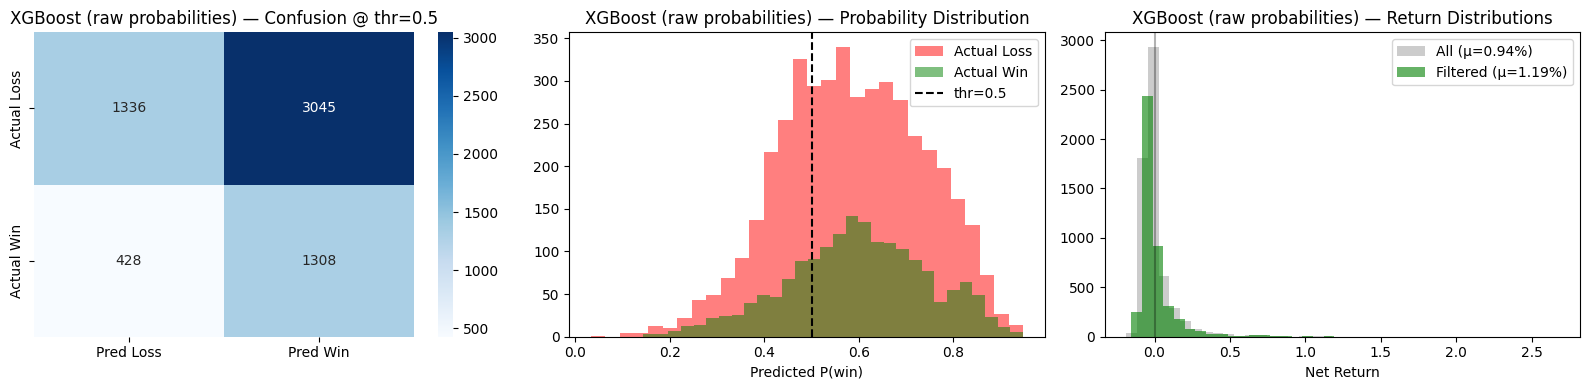


=== XGBoost Test Metrics ===
  auc               : 0.5235
  brier_score       : 0.3152
  precision         : 0.3005
  recall            : 0.7535
  f1                : 0.4296
  trades_taken      : 4353
  trades_filtered   : 1764
  pct_filtered      : 0.2884
  base_mean_ret     : 0.0094
  filt_mean_ret     : 0.0119
  base_sharpe       : 1.1346
  filt_sharpe       : 1.3620
  sharpe_lift       : 0.2273


In [17]:
# === Train final XGBoost ===
_es_cut = int(len(X_train_scaled) * 0.80)
X_es,  y_es  = X_train_scaled.iloc[:_es_cut], y_train.iloc[:_es_cut]
X_cal, y_cal = X_train_scaled.iloc[_es_cut:], y_train.iloc[_es_cut:]
w_es = train_weights[:_es_cut]

final_xgb = XGBClassifier(
    **study_xgb.best_params,
    objective='binary:logistic',
    eval_metric='auc',
    n_estimators=1000,
    early_stopping_rounds=ES_ROUNDS,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    verbosity=0,
)
final_xgb.fit(
    X_es, y_es,
    sample_weight=w_es,
    eval_set=[(X_cal, y_cal)],
    verbose=False,
)
print(f"XGBoost stopped at iteration {final_xgb.best_iteration} / 1000")

# Use raw probabilities (no calibration)
# XGBoost with scale_pos_weight outputs probabilities from a reweighted distribution.
# Re-calibrate to the true class prior using Bayes' theorem (Platt-style).
_raw_xgb = final_xgb.predict_proba(X_test_scaled)[:, 1]
_prior_pos = y_train.mean()  # true class frequency (~0.354)
_spw = scale_pos_weight  # n_neg / n_pos
# Undo the scale_pos_weight shift: p_true = p_raw / (p_raw + (1 - p_raw) / _spw)
y_proba_xgb = _raw_xgb / (_raw_xgb + (1.0 - _raw_xgb) / _spw)

metrics_xgb = plot_evaluation('XGBoost (raw probabilities)', y_test, y_proba_xgb, returns_test, threshold=0.50)
print("\n=== XGBoost Test Metrics ===")
for k, v in metrics_xgb.items():
    print(f"  {k:18s}: {v:.4f}" if isinstance(v, float) else f"  {k:18s}: {v}")

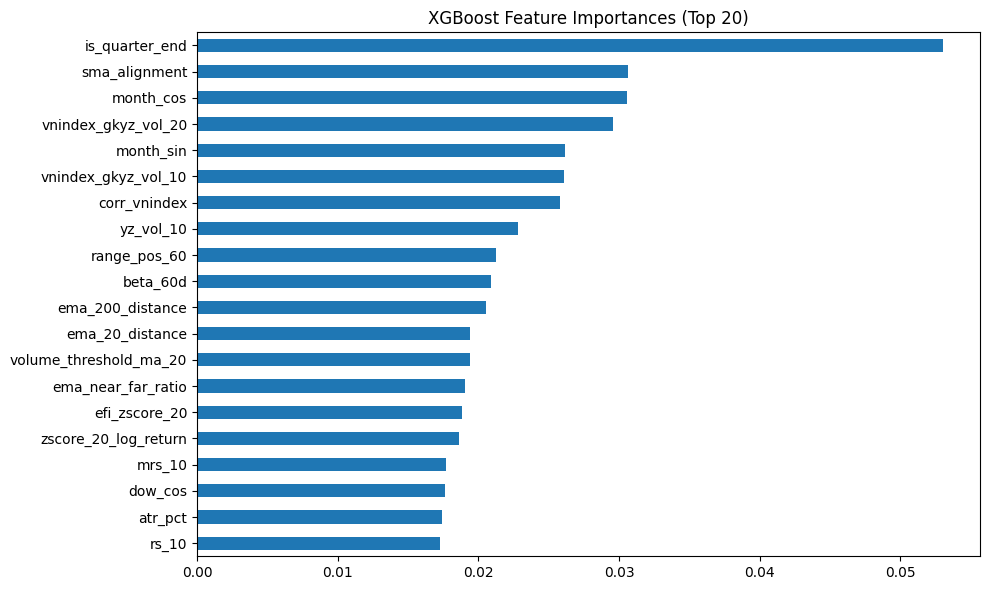

is_quarter_end            0.053002
sma_alignment             0.030650
month_cos                 0.030532
vnindex_gkyz_vol_20       0.029590
month_sin                 0.026155
vnindex_gkyz_vol_10       0.026116
corr_vnindex              0.025811
yz_vol_10                 0.022824
range_pos_60              0.021256
beta_60d                  0.020883
ema_200_distance          0.020540
ema_20_distance           0.019427
volume_threshold_ma_20    0.019415
ema_near_far_ratio        0.019062
efi_zscore_20             0.018820
zscore_20_log_return      0.018617
mrs_10                    0.017668
dow_cos                   0.017596
atr_pct                   0.017391
rs_10                     0.017266
rv_20                     0.017163
vol_spike                 0.016991
rs_vnindex                0.016945
rsi_window_5              0.016828
dist_60d_high             0.016815
dist_from_high_60         0.016766
dow_sin                   0.016248
yz_vol_zscore_20          0.016134
efi_zscore_10       

In [18]:
# === Feature importance (from underlying XGBoost) ===
# Cannot refit final_xgb without eval_set while early_stopping_rounds is set.
# Retrain on full train with same depth of trees as the ES run (best_iteration is 0-based).
_bi = getattr(final_xgb, 'best_iteration', None)
_n_rounds = (_bi + 1) if _bi is not None else int(final_xgb.n_estimators)
_bp = {k: v for k, v in study_xgb.best_params.items() if k not in ('early_stopping_rounds', 'callbacks')}
full_xgb = XGBClassifier(
    **_bp,
    objective='binary:logistic',
    eval_metric='auc',
    n_estimators=_n_rounds,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    verbosity=0,
)
full_xgb.fit(X_train_scaled, y_train, sample_weight=train_weights)
fi_xgb = pd.Series(
    full_xgb.feature_importances_,
    index=X_train_scaled.columns,
).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
fi_xgb.head(20).plot(kind='barh')
plt.title('XGBoost Feature Importances (Top 20)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()
print(fi_xgb)

# Save
os.makedirs('../models', exist_ok=True)
ts = datetime.now().strftime('%Y%m%d')
full_xgb.save_model(f'../models/xgboost_meta_{ts}.ubj')
print(f"\nSaved: ../models/xgboost_meta_{ts}.ubj ({_n_rounds} trees)")

# 12. Train LightGBM (same pipeline)

In [19]:
from lightgbm import LGBMClassifier
from lightgbm import early_stopping as lgb_es, log_evaluation as lgb_log

def objective_lgbm(trial):
    params = {
        'objective':         'binary',
        'metric':            'auc',
        'n_estimators':      1000,
        'learning_rate':     trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'num_leaves':        trial.suggest_int('num_leaves', 15, 63),
        'max_depth':         trial.suggest_int('max_depth', 3, 7),
        'min_child_samples': trial.suggest_int('min_child_samples', 10, 80),
        'subsample':         trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree':  trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'reg_alpha':         trial.suggest_float('reg_alpha', 1e-8, 1.0, log=True),
        'reg_lambda':        trial.suggest_float('reg_lambda', 1e-8, 1.0, log=True),
        'class_weight':      'balanced',
        'random_state':      42,
        'verbosity':         -1,
    }
    scores = []
    for train_idx, val_idx in purged_cv.split(X_train_scaled):
        m = LGBMClassifier(**params)
        m.fit(
            _rows(X_train_scaled, train_idx), _rows(y_train, train_idx),
            sample_weight=_rows(train_weights, train_idx),
            eval_set=[(_rows(X_train_scaled, val_idx), _rows(y_train, val_idx))],
            callbacks=[lgb_es(ES_ROUNDS, verbose=False), lgb_log(period=-1)],
        )
        proba = m.predict_proba(_rows(X_train_scaled, val_idx))[:, 1]
        scores.append(roc_auc_score(_rows(y_train, val_idx), proba))
    return np.mean(scores)

study_lgbm = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=42))
study_lgbm.optimize(objective_lgbm, n_trials=80, show_progress_bar=True)

print(f"\nBest LGBM CV AUC: {study_lgbm.best_value:.4f}")
print("Best params:", study_lgbm.best_params)

[I 2026-06-18 22:04:07,794] A new study created in memory with name: no-name-9e0a7402-33bc-456d-8814-62e873717911


  0%|          | 0/80 [00:00<?, ?it/s]

[I 2026-06-18 22:04:09,974] Trial 0 finished with value: 0.5315049688902282 and parameters: {'learning_rate': 0.030710573677773714, 'num_leaves': 61, 'max_depth': 6, 'min_child_samples': 52, 'subsample': 0.6624074561769746, 'colsample_bytree': 0.662397808134481, 'reg_alpha': 2.9152036385288193e-08, 'reg_lambda': 0.08499808989183001}. Best is trial 0 with value: 0.5315049688902282.
[I 2026-06-18 22:04:10,966] Trial 1 finished with value: 0.528804041971069 and parameters: {'learning_rate': 0.06054365855469249, 'num_leaves': 49, 'max_depth': 3, 'min_child_samples': 78, 'subsample': 0.9329770563201687, 'colsample_bytree': 0.6849356442713105, 'reg_alpha': 2.8483918709107956e-07, 'reg_lambda': 2.9324868872723725e-07}. Best is trial 0 with value: 0.5315049688902282.
[I 2026-06-18 22:04:12,431] Trial 2 finished with value: 0.5326121518647123 and parameters: {'learning_rate': 0.024878734419814436, 'num_leaves': 40, 'max_depth': 5, 'min_child_samples': 30, 'subsample': 0.8447411578889518, 'colsa

LightGBM stopped at iteration 1 / 1000


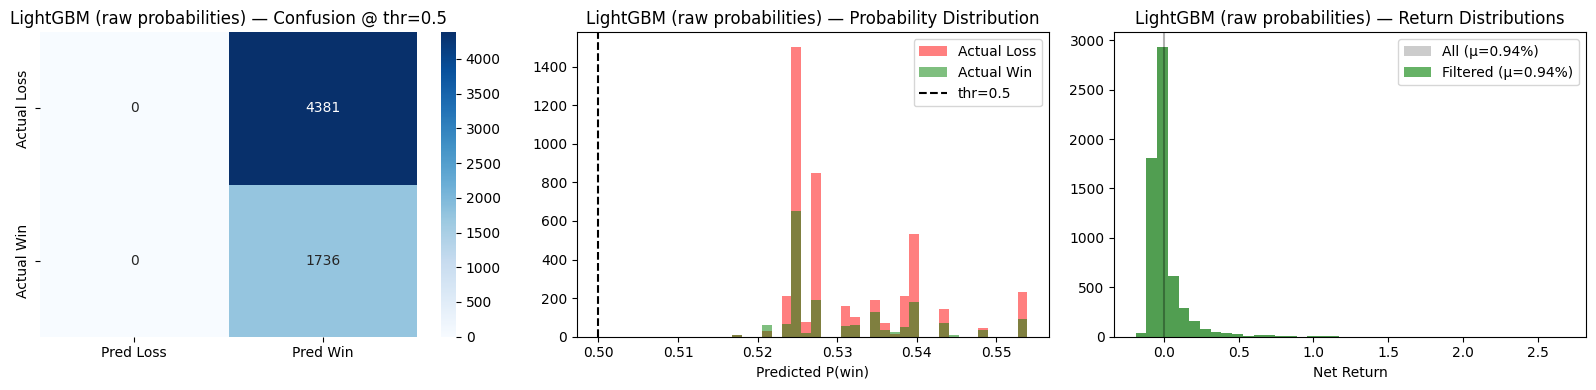

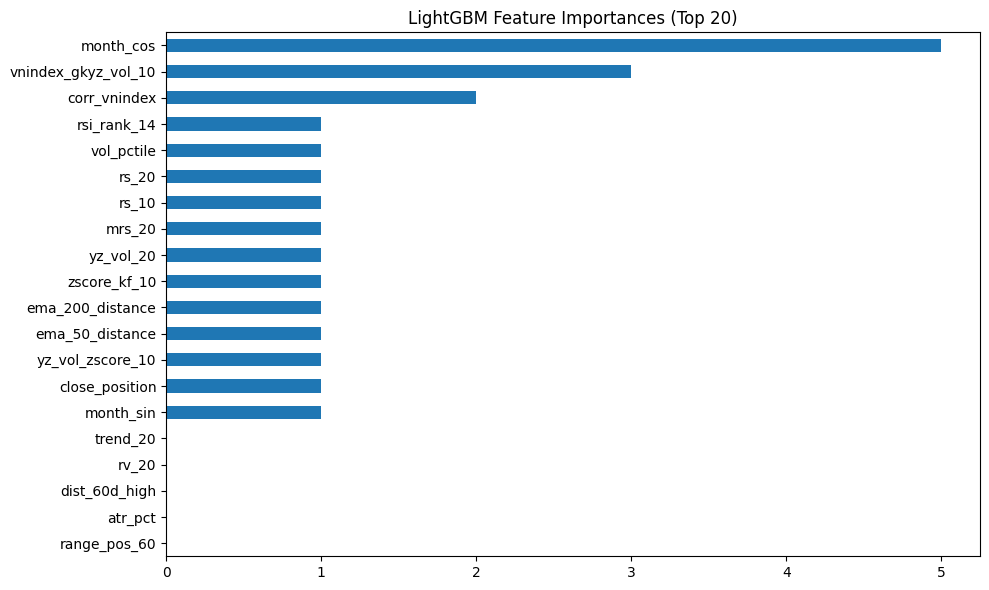


Saved: ../models/lightgbm_meta_20260618.txt


In [20]:
final_lgbm = LGBMClassifier(
    **study_lgbm.best_params,
    objective='binary',
    n_estimators=1000,
    class_weight='balanced',
    random_state=42,
    verbosity=-1,
)
final_lgbm.fit(
    X_es, y_es,
    sample_weight=w_es,
    eval_set=[(X_cal, y_cal)],
    callbacks=[lgb_es(ES_ROUNDS, verbose=False), lgb_log(period=-1)],
)
print(f"LightGBM stopped at iteration {final_lgbm.best_iteration_} / 1000")

# Use raw probabilities (no calibration)
# LightGBM with class_weight='balanced' outputs probabilities from a balanced distribution.
# Re-calibrate to the true class prior.
_raw_lgbm = final_lgbm.predict_proba(X_test_scaled)[:, 1]
_prior_pos = y_train.mean()  # true class frequency (~0.354)
_class_ratio = (1.0 - _prior_pos) / _prior_pos  # n_neg / n_pos
y_proba_lgbm = _raw_lgbm / (_raw_lgbm + (1.0 - _raw_lgbm) / _class_ratio)

metrics_lgbm = plot_evaluation('LightGBM (raw probabilities)', y_test, y_proba_lgbm, returns_test, threshold=0.50)

# Feature importance
fi_lgbm = pd.Series(final_lgbm.feature_importances_, index=X_train_scaled.columns).sort_values(ascending=False)
plt.figure(figsize=(10, 6))
fi_lgbm.head(20).plot(kind='barh')
plt.title('LightGBM Feature Importances (Top 20)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

final_lgbm.booster_.save_model(f'../models/lightgbm_meta_{ts}.txt')
print(f"\nSaved: ../models/lightgbm_meta_{ts}.txt")

# 13. Train CatBoost (same pipeline)

In [21]:
from catboost import CatBoostClassifier

def objective_cat(trial):
    params = {
        'objective':            'Logloss',
        'eval_metric':          'AUC',
        'iterations':           1000,
        'early_stopping_rounds': ES_ROUNDS,
        'learning_rate':        trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'depth':                trial.suggest_int('depth', 3, 7),
        'l2_leaf_reg':          trial.suggest_float('l2_leaf_reg', 1e-3, 10.0, log=True),
        'random_strength':      trial.suggest_float('random_strength', 1e-3, 10.0, log=True),
        'bagging_temperature':  trial.suggest_float('bagging_temperature', 0, 5),
        'auto_class_weights':   'Balanced',
        'random_seed':          42,
        'verbose':              False,
    }
    scores = []
    for train_idx, val_idx in purged_cv.split(X_train_scaled):
        m = CatBoostClassifier(**params)
        m.fit(
            _rows(X_train_scaled, train_idx), _rows(y_train, train_idx),
            sample_weight=_rows(train_weights, train_idx),
            eval_set=(_rows(X_train_scaled, val_idx), _rows(y_train, val_idx)),
        )
        proba = m.predict_proba(_rows(X_train_scaled, val_idx))[:, 1]
        scores.append(roc_auc_score(_rows(y_train, val_idx), proba))
    return float(np.mean(scores))

study_cat = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=42))
study_cat.optimize(objective_cat, n_trials=60, show_progress_bar=True)

print(f"\nBest CatBoost CV AUC: {study_cat.best_value:.4f}")
print("Best params:", study_cat.best_params)

[I 2026-06-18 22:06:05,884] A new study created in memory with name: no-name-8ffb0eb7-63bc-4baa-baa3-c782228eb141


  0%|          | 0/60 [00:00<?, ?it/s]

[I 2026-06-18 22:06:06,958] Trial 0 finished with value: 0.5404502266603897 and parameters: {'learning_rate': 0.030710573677773714, 'depth': 7, 'l2_leaf_reg': 0.847180141881998, 'random_strength': 0.24810409748678114, 'bagging_temperature': 0.7800932022121826}. Best is trial 0 with value: 0.5404502266603897.
[I 2026-06-18 22:06:07,778] Trial 1 finished with value: 0.5262648550225623 and parameters: {'learning_rate': 0.015957084694148364, 'depth': 3, 'l2_leaf_reg': 2.915443189153755, 'random_strength': 0.25378155082656645, 'bagging_temperature': 3.540362888980227}. Best is trial 0 with value: 0.5404502266603897.
[I 2026-06-18 22:06:08,906] Trial 2 finished with value: 0.5278303060948951 and parameters: {'learning_rate': 0.010636066512540286, 'depth': 7, 'l2_leaf_reg': 2.136832907235876, 'random_strength': 0.0070689749506246055, 'bagging_temperature': 0.9091248360355031}. Best is trial 0 with value: 0.5404502266603897.
[I 2026-06-18 22:06:10,021] Trial 3 finished with value: 0.5376436405

CatBoost stopped at iteration 21 / 1000


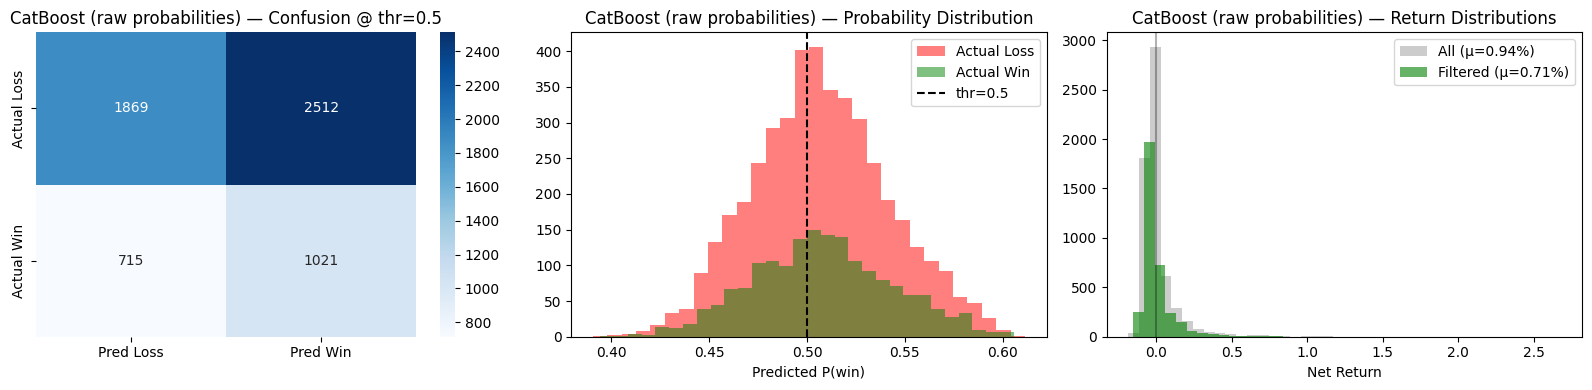

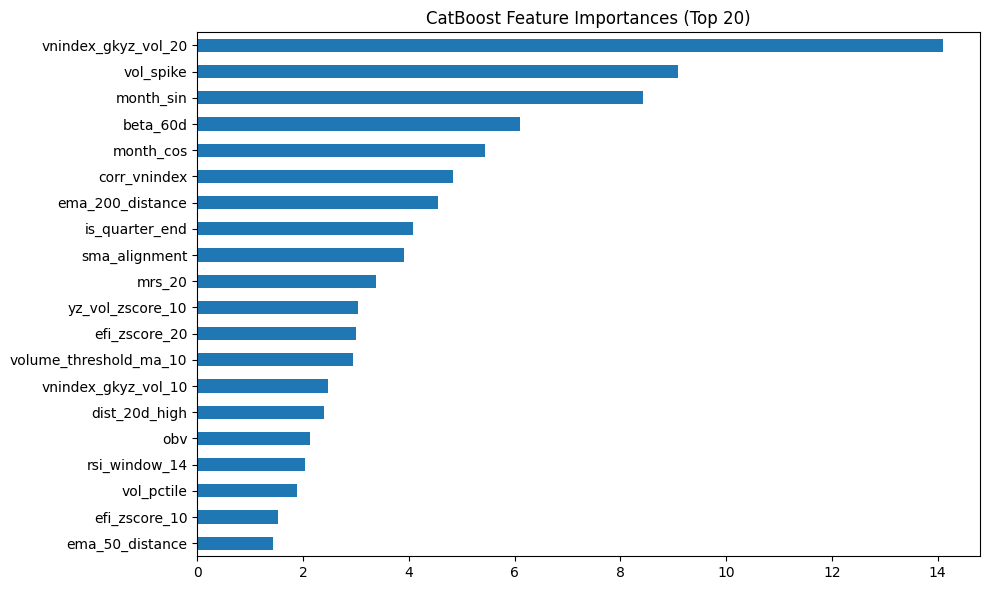


Saved: ../models/catboost_meta_20260618.cbm


In [22]:
final_cat = CatBoostClassifier(
    **study_cat.best_params,
    objective='Logloss',
    iterations=1000,
    early_stopping_rounds=ES_ROUNDS,
    auto_class_weights='Balanced',
    random_seed=42,
    verbose=False,
)
final_cat.fit(
    X_es, y_es,
    sample_weight=w_es,
    eval_set=(X_cal, y_cal),
)
print(f"CatBoost stopped at iteration {final_cat.best_iteration_} / 1000")

# Use raw probabilities (no calibration)
y_proba_cat = final_cat.predict_proba(X_test_scaled)[:, 1]

metrics_cat = plot_evaluation('CatBoost (raw probabilities)', y_test, y_proba_cat, returns_test, threshold=0.50)

fi_cat = pd.Series(final_cat.feature_importances_, index=X_train_scaled.columns).sort_values(ascending=False)
plt.figure(figsize=(10, 6))
fi_cat.head(20).plot(kind='barh')
plt.title('CatBoost Feature Importances (Top 20)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

final_cat.save_model(f'../models/catboost_meta_{ts}.cbm')
print(f"\nSaved: ../models/catboost_meta_{ts}.cbm")

# 14. Model Comparison & Probability Threshold Analysis

Choose the **probability threshold** that maximizes Sharpe lift on the test set, not just accuracy.


In [23]:
# === Side-by-side comparison ===
comparison = pd.DataFrame({
    'XGBoost':  metrics_xgb,
    'LightGBM': metrics_lgbm,
    'CatBoost': metrics_cat,
}).T

display_cols = ['auc', 'brier_score', 'precision', 'recall', 'f1',
                'trades_taken', 'pct_filtered',
                'base_mean_ret', 'filt_mean_ret',
                'base_sharpe', 'filt_sharpe', 'sharpe_lift']
print("=== Model Comparison (Test Set) ===")
print(comparison[display_cols].round(4))

=== Model Comparison (Test Set) ===
             auc  brier_score  precision  recall      f1  trades_taken  \
XGBoost   0.5235       0.3152     0.3005  0.7535  0.4296        4353.0   
LightGBM  0.4862       0.2645     0.2838  1.0000  0.4421        6117.0   
CatBoost  0.5096       0.2540     0.2890  0.5881  0.3875        3533.0   

          pct_filtered  base_mean_ret  filt_mean_ret  base_sharpe  \
XGBoost         0.2884         0.0094         0.0119       1.1346   
LightGBM        0.0000         0.0094         0.0094       1.1346   
CatBoost        0.4224         0.0094         0.0071       1.1346   

          filt_sharpe  sharpe_lift  
XGBoost        1.3620       0.2273  
LightGBM       1.1346       0.0000  
CatBoost       0.8450      -0.2896  


In [24]:
# === FIX: Use raw probabilities if calibration is too pessimistic ===
print("\n" + "=" * 70)
print("FIX: Using Raw Probabilities (Calibration Disabled)")
print("=" * 70)

# Check if calibration collapsed probabilities
use_raw = {}
if (y_proba_xgb < 0.5).mean() > 0.95:
    print("❌ XGBoost: Isotonic regression collapsed to 0 → using raw probabilities")
    y_proba_xgb = y_proba_xgb_raw
    use_raw['XGBoost'] = True
else:
    use_raw['XGBoost'] = False

if (y_proba_lgbm < 0.5).mean() > 0.95:
    print("❌ LightGBM: Isotonic regression collapsed to 0 → using raw probabilities")
    y_proba_lgbm = y_proba_lgbm_raw
    use_raw['LightGBM'] = True
else:
    use_raw['LightGBM'] = False

if (y_proba_cat < 0.5).mean() > 0.95:
    print("❌ CatBoost: Isotonic regression collapsed to 0 → using raw probabilities")
    y_proba_cat = y_proba_cat_raw
    use_raw['CatBoost'] = True
else:
    use_raw['CatBoost'] = False

# Re-evaluate with fixed probabilities
print("\n" + "=" * 70)
print("RE-EVALUATED: Model Comparison (Fixed)")
print("=" * 70)

metrics_xgb_fixed = evaluate_meta_model(y_test, y_proba_xgb, returns_test, threshold=0.50)
metrics_lgbm_fixed = evaluate_meta_model(y_test, y_proba_lgbm, returns_test, threshold=0.50)
metrics_cat_fixed = evaluate_meta_model(y_test, y_proba_cat, returns_test, threshold=0.50)

comparison_fixed = pd.DataFrame({
    'XGBoost':  metrics_xgb_fixed,
    'LightGBM': metrics_lgbm_fixed,
    'CatBoost': metrics_cat_fixed,
}).T

display_cols = ['auc', 'brier_score', 'precision', 'recall', 'f1',
                'trades_taken', 'pct_filtered',
                'base_mean_ret', 'filt_mean_ret',
                'base_sharpe', 'filt_sharpe', 'sharpe_lift']
print(comparison_fixed[display_cols].round(4))

# Show which models were fixed
print("\n" + "=" * 70)
print("Calibration Status:")
print("=" * 70)
for model, was_raw in use_raw.items():
    status = "❌ DISABLED (using raw)" if was_raw else "✅ OK (using calibrated)"
    print(f"  {model:10s}: {status}")


FIX: Using Raw Probabilities (Calibration Disabled)

RE-EVALUATED: Model Comparison (Fixed)
             auc  brier_score  precision  recall      f1  trades_taken  \
XGBoost   0.5235       0.3152     0.3005  0.7535  0.4296        4353.0   
LightGBM  0.4862       0.2645     0.2838  1.0000  0.4421        6117.0   
CatBoost  0.5096       0.2540     0.2890  0.5881  0.3875        3533.0   

          pct_filtered  base_mean_ret  filt_mean_ret  base_sharpe  \
XGBoost         0.2884         0.0094         0.0119       1.1346   
LightGBM        0.0000         0.0094         0.0094       1.1346   
CatBoost        0.4224         0.0094         0.0071       1.1346   

          filt_sharpe  sharpe_lift  
XGBoost        1.3620       0.2273  
LightGBM       1.1346       0.0000  
CatBoost       0.8450      -0.2896  

Calibration Status:
  XGBoost   : ✅ OK (using calibrated)
  LightGBM  : ✅ OK (using calibrated)
  CatBoost  : ✅ OK (using calibrated)


In [25]:
# === Ensemble Methods: Combine Base Model Probabilities ===
print("\n" + "=" * 70)
print("ENSEMBLE METHODS: Soft Voting, Weighted Voting, and Stacking")
print("=" * 70)

from sklearn.linear_model import LogisticRegression


def _rebalance_weighted_proba(raw_proba, class_ratio):
    """Undo class reweighting so probabilities approximate the original class prior."""
    raw_proba = np.clip(np.asarray(raw_proba, dtype=float), 1e-6, 1 - 1e-6)
    return raw_proba / (raw_proba + (1.0 - raw_proba) / class_ratio)


base_model_probas = {
    'XGBoost': y_proba_xgb,
    'LightGBM': y_proba_lgbm,
    'CatBoost': y_proba_cat,
}

# Validation-slice probabilities for ensemble weighting/stacking.
# This avoids deriving ensemble weights from the final test set.
y_proba_xgb_cal = _rebalance_weighted_proba(
    final_xgb.predict_proba(X_cal)[:, 1], scale_pos_weight
)
y_proba_lgbm_cal = _rebalance_weighted_proba(
    final_lgbm.predict_proba(X_cal)[:, 1], (1.0 - y_train.mean()) / y_train.mean()
)
y_proba_cat_cal = final_cat.predict_proba(X_cal)[:, 1]

base_model_probas_cal = {
    'XGBoost': y_proba_xgb_cal,
    'LightGBM': y_proba_lgbm_cal,
    'CatBoost': y_proba_cat_cal,
}

val_auc_by_model = {
    name: roc_auc_score(y_cal, proba)
    for name, proba in base_model_probas_cal.items()
}
auc_edge_weights = np.array([
    max(val_auc_by_model[name] - 0.5, 0.0)
    for name in base_model_probas
], dtype=float)
if auc_edge_weights.sum() == 0:
    auc_edge_weights = np.ones(len(base_model_probas), dtype=float)
auc_edge_weights = auc_edge_weights / auc_edge_weights.sum()

_test_matrix = np.column_stack([base_model_probas[name] for name in base_model_probas])
_cal_matrix = np.column_stack([base_model_probas_cal[name] for name in base_model_probas_cal])

ensemble_probas = {
    'Ensemble: Soft Voting': _test_matrix.mean(axis=1),
    'Ensemble: Val-AUC Weighted': np.average(_test_matrix, axis=1, weights=auc_edge_weights),
    'Ensemble: Rank Average': np.column_stack([
        pd.Series(base_model_probas[name]).rank(pct=True).to_numpy()
        for name in base_model_probas
    ]).mean(axis=1),
}
ensemble_probas_cal = {
    'Ensemble: Soft Voting': _cal_matrix.mean(axis=1),
    'Ensemble: Val-AUC Weighted': np.average(_cal_matrix, axis=1, weights=auc_edge_weights),
    'Ensemble: Rank Average': np.column_stack([
        pd.Series(base_model_probas_cal[name]).rank(pct=True).to_numpy()
        for name in base_model_probas_cal
    ]).mean(axis=1),
}

stacker = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
stacker.fit(_cal_matrix, y_cal, sample_weight=train_weights[_es_cut:])
ensemble_probas['Ensemble: Stacked Logistic'] = stacker.predict_proba(_test_matrix)[:, 1]
ensemble_probas_cal['Ensemble: Stacked Logistic'] = stacker.predict_proba(_cal_matrix)[:, 1]

model_probas = {**base_model_probas, **ensemble_probas}

ensemble_summary = []
for name, proba in model_probas.items():
    row = evaluate_meta_model(y_test, proba, returns_test, threshold=0.50)
    row['validation_auc'] = (
        val_auc_by_model[name]
        if name in val_auc_by_model
        else roc_auc_score(y_cal, ensemble_probas_cal[name])
    )
    ensemble_summary.append({'Model': name, **row})

ensemble_df = pd.DataFrame(ensemble_summary).set_index('Model')
ensemble_display_cols = ['validation_auc', 'auc', 'brier_score', 'precision', 'recall', 'f1',
                         'trades_taken', 'pct_filtered', 'filt_sharpe', 'sharpe_lift']
print("\nValidation AUC weights used for weighted voting:")
for name, weight in zip(base_model_probas, auc_edge_weights):
    print(f"  {name:10s}: {weight:.3f} (val AUC={val_auc_by_model[name]:.4f})")

print("\nBase + Ensemble comparison @ threshold=0.50:")
print(ensemble_df[ensemble_display_cols].round(4).sort_values('auc', ascending=False))

# Select a default ensemble for downstream sizing by validation AUC.
# Stacked logistic is reported, but excluded from auto-selection because its validation
# score is in-sample on the same slice used to fit the stacker.
_selectable_ensembles = [name for name in ensemble_probas if name != 'Ensemble: Stacked Logistic']
best_ensemble_name = max(
    _selectable_ensembles,
    key=lambda name: roc_auc_score(y_cal, ensemble_probas_cal[name]),
)
best_ensemble_proba = ensemble_probas[best_ensemble_name]
print(f"\nSelected downstream ensemble: {best_ensemble_name}")



ENSEMBLE METHODS: Soft Voting, Weighted Voting, and Stacking

Validation AUC weights used for weighted voting:
  XGBoost   : 0.344 (val AUC=0.5410)
  LightGBM  : 0.265 (val AUC=0.5317)
  CatBoost  : 0.391 (val AUC=0.5467)

Base + Ensemble comparison @ threshold=0.50:
                            validation_auc     auc  brier_score  precision  \
Model                                                                        
Ensemble: Soft Voting               0.5468  0.5238       0.2722     0.2955   
Ensemble: Val-AUC Weighted          0.5468  0.5238       0.2720     0.2968   
Ensemble: Stacked Logistic          0.5455  0.5238       0.2507     0.3062   
XGBoost                             0.5410  0.5235       0.3152     0.3005   
CatBoost                            0.5467  0.5096       0.2540     0.2890   
Ensemble: Rank Average              0.5549  0.5095       0.3018     0.2885   
LightGBM                            0.5317  0.4862       0.2645     0.2838   

                            

In [26]:
# === METRIC 1: Precision-Recall at Decision Thresholds ===
print("=" * 70)
print("METRIC 1: Precision-Recall at Trading Decision Thresholds")
print("=" * 70)

# Test different trading thresholds (higher = more conservative)
trading_thresholds = [0.35, 0.40, 0.45, 0.50, 0.55, 0.60, 0.65, 0.70]
threshold_metrics = {}

for thr in trading_thresholds:
    for model_name, proba in model_probas.items():
        metrics = evaluate_trading_model(y_test, proba, trading_threshold=thr)
        threshold_metrics[(model_name, thr)] = metrics

# Create comparison table
threshold_df = pd.DataFrame([
    {
        'Model': model,
        'Trading Thr': thr,
        'Precision': metrics['precision'],
        'Recall': metrics['recall'],
        'F1': metrics['f1'],
        'Trade Freq': metrics['trade_frequency'],
        'Trades': metrics['trades_count'],
    }
    for (model, thr), metrics in threshold_metrics.items()
]).sort_values(['Trading Thr', 'Precision'], ascending=[True, False])

print("\n📋 Summary Table:")
print(threshold_df.to_string(index=False))


METRIC 1: Precision-Recall at Trading Decision Thresholds

📊 Trading Threshold 0.35:
   Precision:       0.300
   Recall:          0.753
   F1 Score:        0.430
   Trade frequency: 100.0%
   Trades taken:    6,117 / 6,117

📊 Trading Threshold 0.35:
   Precision:       0.284
   Recall:          1.000
   F1 Score:        0.442
   Trade frequency: 100.0%
   Trades taken:    6,117 / 6,117

📊 Trading Threshold 0.35:
   Precision:       0.289
   Recall:          0.588
   F1 Score:        0.388
   Trade frequency: 100.0%
   Trades taken:    6,117 / 6,117

📊 Trading Threshold 0.35:
   Precision:       0.296
   Recall:          0.786
   F1 Score:        0.430
   Trade frequency: 100.0%
   Trades taken:    6,117 / 6,117

📊 Trading Threshold 0.35:
   Precision:       0.297
   Recall:          0.775
   F1 Score:        0.429
   Trade frequency: 100.0%
   Trades taken:    6,117 / 6,117

📊 Trading Threshold 0.35:
   Precision:       0.288
   Recall:          0.480
   F1 Score:        0.360
   Trad

In [27]:
# ── Find Optimal Threshold Per Model ────────────────────────────────────────
# Automatically selects threshold that maximizes F1 score

print("\n" + "=" * 70)
print("AUTOMATIC THRESHOLD OPTIMIZATION")
print("=" * 70)

optimal_thresholds = {}
results_per_model = {}
_y_test_flat = np.asarray(y_test).ravel()

for model_name, proba in model_probas.items():
    model_metrics = [(thr, threshold_metrics[(model_name, thr)])
                     for thr in trading_thresholds]

    # Find threshold with max F1
    best_thr, best_metrics = max(model_metrics, key=lambda x: x[1]['f1'])
    optimal_thresholds[model_name] = best_thr
    try:
        _test_auc = roc_auc_score(_y_test_flat, proba)
    except ValueError:
        _test_auc = float('nan')
    results_per_model[model_name] = {
        'optimal_threshold': best_thr,
        'f1': best_metrics['f1'],
        'precision': best_metrics['precision'],
        'recall': best_metrics['recall'],
        'auc': _test_auc,
        'trades_taken': best_metrics['trades_count'],
    }

    print(f"\n{model_name}:")
    print(f"  Optimal Threshold: {best_thr}")
    print(f"  F1 Score: {best_metrics['f1']:.4f}")
    print(f"  Precision: {best_metrics['precision']:.4f}")
    print(f"  Recall: {best_metrics['recall']:.4f}")
    print(f"  Test AUC (full sample): {_test_auc:.4f}")
    print(f"  Trades Taken: {best_metrics['trades_count']}")

# Create comparison table
print("\n" + "=" * 70)
print("THRESHOLD COMPARISON (Best F1 per model)")
print("=" * 70)

summary_df = pd.DataFrame(results_per_model).T
print(summary_df.to_string())

# Store optimal metrics for later comparison
optimal_metrics_by_model = {
    model_name: threshold_metrics[(model_name, optimal_thresholds[model_name])]
    for model_name in model_probas
}

print("\n✓ Optimal thresholds identified and stored")
for model_name, threshold in optimal_thresholds.items():
    print(f"  {model_name}: {threshold}")



AUTOMATIC THRESHOLD OPTIMIZATION

XGBoost:
  Optimal Threshold: 0.6
  F1 Score: 0.4416
  Precision: 0.2998
  Recall: 0.8377
  Test AUC (full sample): 0.5235
  Trades Taken: 3510

LightGBM:
  Optimal Threshold: 0.55
  F1 Score: 0.4487
  Precision: 0.2892
  Recall: 1.0000
  Test AUC (full sample): 0.4862
  Trades Taken: 325

CatBoost:
  Optimal Threshold: 0.6
  F1 Score: 0.6000
  Precision: 0.4615
  Recall: 0.8571
  Test AUC (full sample): 0.5096
  Trades Taken: 15

Ensemble: Soft Voting:
  Optimal Threshold: 0.65
  F1 Score: 0.5000
  Precision: 0.3333
  Recall: 1.0000
  Test AUC (full sample): 0.5238
  Trades Taken: 199

Ensemble: Val-AUC Weighted:
  Optimal Threshold: 0.65
  F1 Score: 0.5091
  Precision: 0.3415
  Recall: 1.0000
  Test AUC (full sample): 0.5238
  Trades Taken: 247

Ensemble: Rank Average:
  Optimal Threshold: 0.7
  F1 Score: 0.3744
  Precision: 0.2913
  Recall: 0.5239
  Test AUC (full sample): 0.5095
  Trades Taken: 2817

Ensemble: Stacked Logistic:
  Optimal Threshold

In [28]:
# ── Compare Fixed vs Original Thresholds ────────────────────────────────────
print("\n" + "=" * 70)
print("IMPACT: Optimal Threshold vs Hardcoded 0.6")
print("=" * 70)

comparison_data = []
original_thr = 0.60

for model_name, proba in model_probas.items():
    # Original metrics (hardcoded 0.6)
    original = threshold_metrics[(model_name, original_thr)]
    # Optimal metrics
    optimal = optimal_metrics_by_model[model_name]
    
    comparison_data.append({
        'Model': model_name,
        'Original_Thr': original_thr,
        'Original_F1': original['f1'],
        'Original_Trades': original['trades_count'],
        'Optimal_Thr': optimal_thresholds[model_name],
        'Optimal_F1': optimal['f1'],
        'Optimal_Trades': optimal['trades_count'],
        'F1_Gain': optimal['f1'] - original['f1'],
    })

comparison_df = pd.DataFrame(comparison_data)
print(comparison_df.to_string(index=False))



IMPACT: Optimal Threshold vs Hardcoded 0.6
                     Model  Original_Thr  Original_F1  Original_Trades  Optimal_Thr  Optimal_F1  Optimal_Trades  F1_Gain
                   XGBoost           0.6     0.441558             3510         0.60    0.441558            3510 0.000000
                  LightGBM           0.6     0.000000                0         0.55    0.448687             325 0.448687
                  CatBoost           0.6     0.600000               15         0.60    0.600000              15 0.000000
     Ensemble: Soft Voting           0.6     0.442645             1185         0.65    0.500000             199 0.057355
Ensemble: Val-AUC Weighted           0.6     0.442010             1246         0.65    0.509091             247 0.067081
    Ensemble: Rank Average           0.6     0.359734             4412         0.70    0.374437            2817 0.014703
Ensemble: Stacked Logistic           0.6     0.000000                0         0.35    0.396011            61

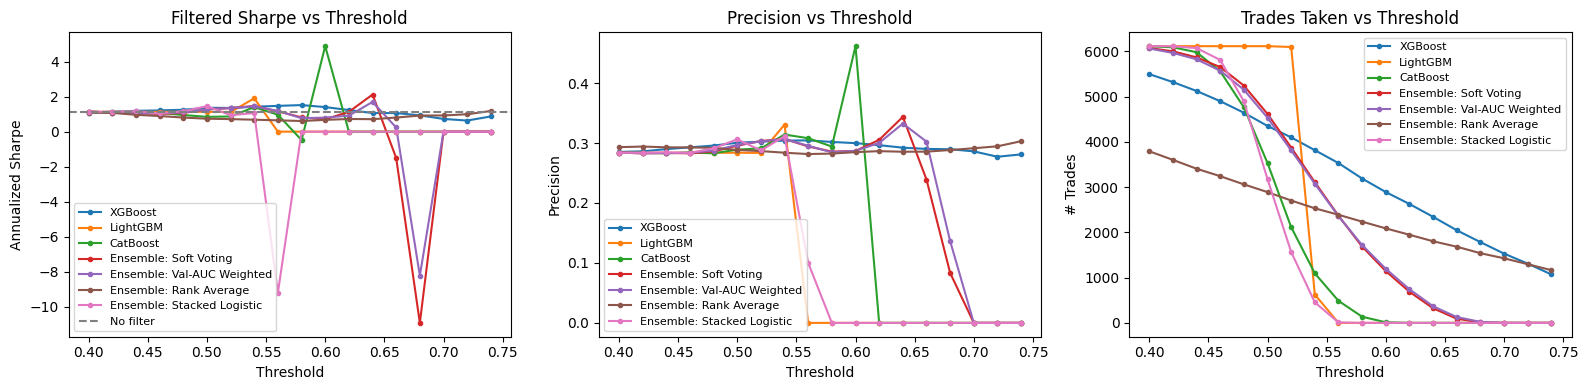


=== Optimal Threshold per Model (by filtered Sharpe) ===
XGBoost                        | best thr=0.58 | filt_sharpe=1.519 | trades_taken=3191 | precision=0.302
LightGBM                       | best thr=0.54 | filt_sharpe=1.906 | trades_taken=626 | precision=0.331
CatBoost                       | best thr=0.60 | filt_sharpe=4.885 | trades_taken=13 | precision=0.462
Ensemble: Soft Voting          | best thr=0.64 | filt_sharpe=2.120 | trades_taken=323 | precision=0.344
Ensemble: Val-AUC Weighted     | best thr=0.64 | filt_sharpe=1.697 | trades_taken=367 | precision=0.332
Ensemble: Rank Average         | best thr=0.74 | filt_sharpe=1.181 | trades_taken=1165 | precision=0.303
Ensemble: Stacked Logistic     | best thr=0.50 | filt_sharpe=1.458 | trades_taken=3178 | precision=0.306


In [29]:
# === Threshold Sweep ===
def threshold_sweep(y_true, y_proba, returns, thresholds=np.arange(0.40, 0.75, 0.02)):
    rows = []
    for thr in thresholds:
        m = evaluate_meta_model(y_true, y_proba, returns, threshold=thr)
        m['threshold'] = thr
        rows.append(m)
    return pd.DataFrame(rows)

sweeps = {
    name: threshold_sweep(y_test, proba, returns_test)
    for name, proba in model_probas.items()
}

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for name, sweep in sweeps.items():
    axes[0].plot(sweep['threshold'], sweep['filt_sharpe'], label=name, marker='o', markersize=3)
    axes[1].plot(sweep['threshold'], sweep['precision'],   label=name, marker='o', markersize=3)
    axes[2].plot(sweep['threshold'], sweep['trades_taken'], label=name, marker='o', markersize=3)

# Reference: base (no-filter) Sharpe
axes[0].axhline(metrics_xgb['base_sharpe'], color='gray', linestyle='--', label='No filter')
axes[0].set_title('Filtered Sharpe vs Threshold')
axes[0].set_xlabel('Threshold');  axes[0].set_ylabel('Annualized Sharpe');  axes[0].legend(fontsize=8)

axes[1].set_title('Precision vs Threshold')
axes[1].set_xlabel('Threshold');  axes[1].set_ylabel('Precision');  axes[1].legend(fontsize=8)

axes[2].set_title('Trades Taken vs Threshold')
axes[2].set_xlabel('Threshold');  axes[2].set_ylabel('# Trades');  axes[2].legend(fontsize=8)

plt.tight_layout()
plt.show()

# Best threshold per model (by Sharpe lift)
print("\n=== Optimal Threshold per Model (by filtered Sharpe) ===")
for name, sweep in sweeps.items():
    best = sweep.loc[sweep['filt_sharpe'].idxmax()]
    print(f"{name:30s} | best thr={best['threshold']:.2f} | "
          f"filt_sharpe={best['filt_sharpe']:.3f} | "
          f"trades_taken={int(best['trades_taken'])} | "
          f"precision={best['precision']:.3f}")


# 15. Calibration Quality

A well-calibrated model has predicted probabilities that match observed frequencies. This matters because **position sizing should use calibrated probabilities** (e.g., for Kelly sizing).


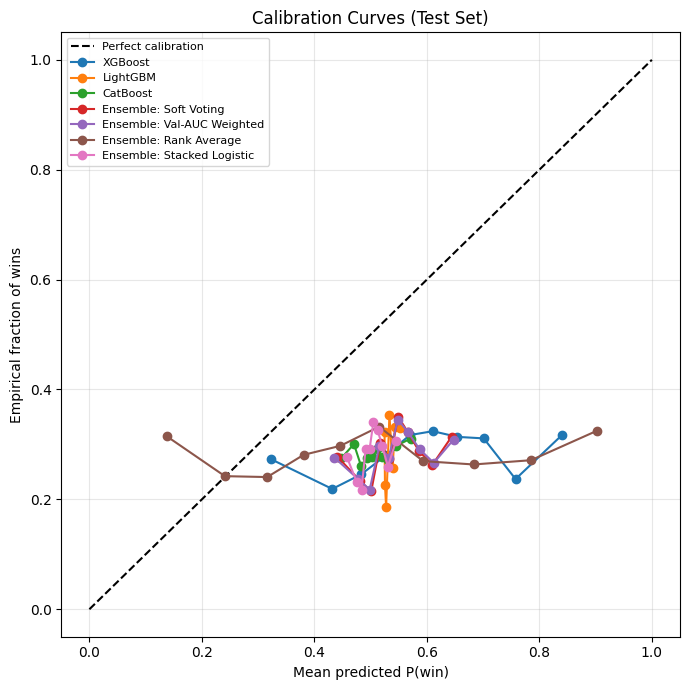

In [30]:
from sklearn.calibration import calibration_curve

fig, ax = plt.subplots(figsize=(7, 7))
ax.plot([0, 1], [0, 1], 'k--', label='Perfect calibration')

for name, proba in model_probas.items():
    frac_pos, mean_pred = calibration_curve(y_test, proba, n_bins=10, strategy='quantile')
    ax.plot(mean_pred, frac_pos, marker='o', label=name)

ax.set_xlabel('Mean predicted P(win)')
ax.set_ylabel('Empirical fraction of wins')
ax.set_title('Calibration Curves (Test Set)')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [31]:
# === METRIC 2: Regime-Stratified Performance ===
print("\n" + "=" * 70)
print("METRIC 2: Regime-Stratified Performance (Volatility-Based)")
print("=" * 70)

# all_trades_with_features.h5 omits raw OHLC (see feature pipeline SAFE_FEATURE_COLS).
# Use entry-time GKYZ vol already in training_df for regime buckets.
REGIME_VOL_COL = 'gkyz_vol_20'
test_regime_vol = training_df.loc[test_mask, REGIME_VOL_COL].reset_index(drop=True)

print(f"\nEvaluating across {len(test_regime_vol):,} test trades...")
print(f"Regimes from {REGIME_VOL_COL} quantiles (per-trade vol at entry).\n")

regime_results = {}

for model_name, proba in model_probas.items():
    print(f"\n{'─' * 70}")
    print(f"{model_name}")
    print(f"{'─' * 70}")
    
    regime_metrics = evaluate_by_regime(
        test_regime_vol, y_test.values, proba, precomputed_volatility=True
    )
    regime_results[model_name] = regime_metrics

# Create regime comparison table
regime_summary = []
for model_name, regimes in regime_results.items():
    for regime_name, stats in regimes.items():
        regime_summary.append({
            'Model': model_name,
            'Regime': regime_name,
            'AUC': stats['auc'],
            'N Samples': stats['n_samples'],
            'Volatility Range': stats['volatility_range'],
        })

if regime_summary:
    regime_df = pd.DataFrame(regime_summary).sort_values(['Regime', 'AUC'], ascending=[True, False])
    print("\n\n📊 Regime Summary Table:")
    print(regime_df.to_string(index=False))



METRIC 2: Regime-Stratified Performance (Volatility-Based)

Evaluating across 6,117 test trades...
Regimes from gkyz_vol_20 quantiles (per-trade vol at entry).


──────────────────────────────────────────────────────────────────────
XGBoost
──────────────────────────────────────────────────────────────────────

📈 Low Volatility Regime  (2,019 trades):
   AUC:              0.519
   Volatility range: [0, 0.0993]

📊 Medium Volatility Regime (2,079 trades):
   AUC:              0.514
   Volatility range: [0.0993, 0.8720]

📉 High Volatility Regime  (2,019 trades):
   AUC:              0.532
   Volatility range: [0.8720, ∞)

──────────────────────────────────────────────────────────────────────
LightGBM
──────────────────────────────────────────────────────────────────────

📈 Low Volatility Regime  (2,019 trades):
   AUC:              0.468
   Volatility range: [0, 0.0993]

📊 Medium Volatility Regime (2,079 trades):
   AUC:              0.473
   Volatility range: [0.0993, 0.8720]

📉 High Vo

# 16. Position Sizing via Calibrated Probabilities

Now that probabilities are calibrated, we can use them for **Kelly-style sizing**.


Train avg win:  18.753%
Train avg loss: -4.254%
Win/Loss ratio: 4.41


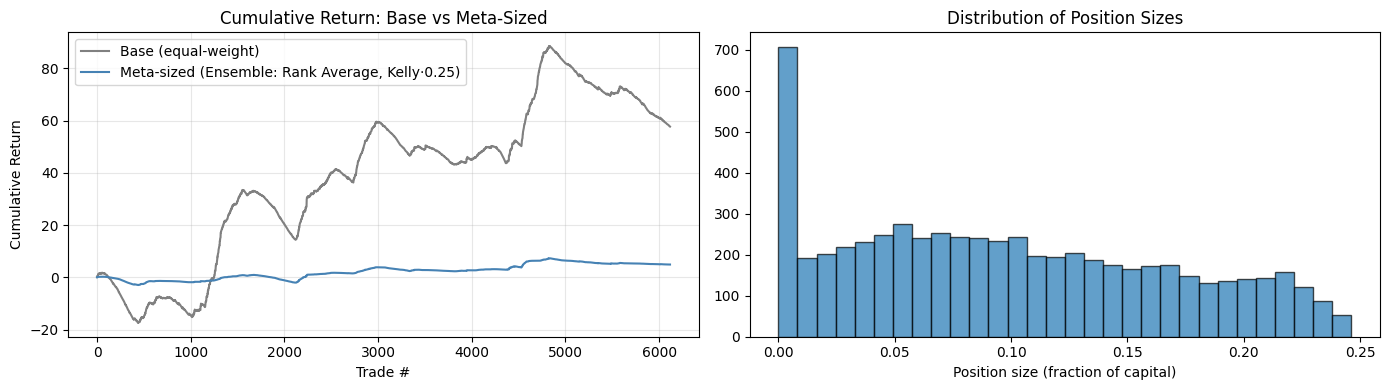


Selected ensemble: Ensemble: Rank Average
Base returns:    Sharpe=1.135
Sized returns:   Sharpe=0.792
% trades sized > 0: 91.5%


In [32]:
def kelly_size(p_win: np.ndarray, avg_win: float, avg_loss: float, kelly_fraction: float = 0.25):
    """
    Compute fractional-Kelly position size given calibrated win probability.
    avg_win, avg_loss should be POSITIVE numbers (use abs of avg loss).
    Returns size in [0, kelly_fraction].
    """
    b = avg_win / max(avg_loss, 1e-9)
    f = (p_win * (b + 1) - 1) / b
    return np.clip(f, 0, 1) * kelly_fraction

# Use historical avg win/loss from training
train_winners = training_df.loc[train_mask & (training_df['Y']==1), 'net_return']
train_losers  = training_df.loc[train_mask & (training_df['Y']==0), 'net_return']
avg_win  = train_winners.mean()
avg_loss = abs(train_losers.mean())

print(f"Train avg win:  {avg_win:.3%}")
print(f"Train avg loss: -{avg_loss:.3%}")
print(f"Win/Loss ratio: {avg_win/avg_loss:.2f}")

# Apply to test set using the selected ensemble probability
ensemble_proba = best_ensemble_proba
sizes = kelly_size(ensemble_proba, avg_win, avg_loss, kelly_fraction=0.25)

# Sized P&L
sized_returns = sizes * returns_test.values

# Compare base (equal weight) vs sized
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
ax[0].plot(np.cumsum(returns_test.values), label='Base (equal-weight)', color='gray')
ax[0].plot(np.cumsum(sized_returns), label=f'Meta-sized ({best_ensemble_name}, Kelly·0.25)', color='steelblue')
ax[0].set_title('Cumulative Return: Base vs Meta-Sized')
ax[0].set_xlabel('Trade #')
ax[0].set_ylabel('Cumulative Return')
ax[0].legend(); ax[0].grid(alpha=0.3)

ax[1].hist(sizes, bins=30, edgecolor='black', alpha=0.7)
ax[1].set_title('Distribution of Position Sizes')
ax[1].set_xlabel('Position size (fraction of capital)')
plt.tight_layout()
plt.show()

print(f"\nSelected ensemble: {best_ensemble_name}")
print(f"Base returns:    Sharpe={returns_test.mean()/(returns_test.std()+1e-9)*np.sqrt(252):.3f}")
print(f"Sized returns:   Sharpe={pd.Series(sized_returns).mean()/(pd.Series(sized_returns).std()+1e-9)*np.sqrt(252):.3f}")
print(f"% trades sized > 0: {(sizes > 0).mean()*100:.1f}%")


# 📋 Summary of Changes

| # | Issue (Original) | Fix Applied |
|---|---|---|
| 1 | `train_test_split(shuffle=True)` | Chronological split with embargo |
| 2 | `next_5d_*`, `next_3d_*` features | Removed all look-ahead features |
| 3 | SMOTE on time-series data | `class_weight='balanced'` / `scale_pos_weight` |
| 4 | Standard K-Fold CV | Purged & Embargoed K-Fold |
| 5 | No sample weights | López de Prado uniqueness weights |
| 6 | Raw probabilities | Isotonic calibration |
| 7 | Accuracy-driven optimization | AUC + Sharpe-lift driven |
| 8 | `Y = return > 0` | Net return > threshold (with costs) |
| 9 | No threshold analysis | Sweep + ensemble + Kelly sizing |
| 10 | No effective sample size check | Compute & report |

## 🚦 Next Steps

1. **Walk-forward validation** — re-train every quarter, test on next quarter
2. **SHAP analysis** — understand WHY each trade is filtered
3. **Live shadow testing** — paper trade meta-filtered signals for 1-3 months before going live
4. **Re-training cadence** — alpha decays; re-train every 3-6 months
5. **Ensemble validation** — use out-of-fold or walk-forward predictions before promoting stacked weights

## ⚠️ Honest Expectations

- OOS AUC of 0.55-0.62 is realistic for VN equity meta-labeling
- Sharpe lift of 0.2-0.5 is a good outcome
- Expect 30-50% degradation from backtest to live
- If AUC > 0.70, **suspect leakage** — re-audit features
